## Backward Calculation of Implied Probabilities - Start: Feb 2025

In [ ]:
import pandas as pd
import numpy as np

cme_feb_2025 = pd.read_csv("../../data/raw/CME/CME_FEB_2025.csv")
cme_feb_2025 = cme_feb_2025.reset_index(drop = True)
cme_feb_2025["time"] = pd.to_datetime(cme_feb_2025["time"],unit="s") 

In [ ]:
cme_feb_2025

,time,open,high,low,close,Volume
0,2024-08-01 05:25:00,95.5800,95.5800,95.5800,95.5800,5
1,2024-08-01 05:26:00,95.5800,95.5800,95.5800,95.5800,2
2,2024-08-01 05:41:00,95.5850,95.5850,95.5850,95.5850,6
3,2024-08-01 06:12:00,95.5800,95.5800,95.5800,95.5800,2
4,2024-08-01 06:19:00,95.5800,95.5800,95.5800,95.5800,8
...,...,...,...,...,...,...
36813,2025-02-28 16:16:00,95.6675,95.6675,95.6675,95.6675,1
36814,2025-02-28 16:37:00,95.6700,95.6700,95.6700,95.6700,4285
36815,2025-02-28 16:43:00,95.6700,95.6700,95.6700,95.6700,2
36816,2025-02-28 17:21:00,95.6700,95.6700,95.6700,95.6700,1


## CME End: Jan 2025

In [ ]:
cme_jan_2025 = pd.read_csv("../../data/raw/CME/CME_JAN_2025.csv")
cme_jan_2025 = cme_jan_2025.reset_index(drop = True)
cme_jan_2025["time"] = pd.to_datetime(cme_jan_2025["time"],unit="s") 

In [ ]:
cme_jan_2025

,time,open,high,low,close,Volume
0,2024-08-01 05:00:00,95.40,95.40,95.40,95.40,18
1,2024-08-01 05:01:00,95.40,95.40,95.40,95.40,3
2,2024-08-01 05:14:00,95.40,95.40,95.40,95.40,27
3,2024-08-01 05:25:00,95.40,95.40,95.40,95.40,24
4,2024-08-01 05:26:00,95.40,95.40,95.40,95.40,14
...,...,...,...,...,...,...
34903,2025-01-31 20:59:00,95.67,95.67,95.67,95.67,3
34904,2025-01-31 21:01:00,95.67,95.67,95.67,95.67,5
34905,2025-01-31 21:26:00,95.67,95.67,95.67,95.67,98
34906,2025-01-31 21:39:00,95.67,95.67,95.67,95.67,1


## Merge

In [ ]:
feb = cme_feb_2025.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")

if feb["time"].dt.tz is None:
    feb["time"] = feb["time"].dt.tz_localize("UTC")
else:
    feb["time"] = feb["time"].dt.tz_convert("UTC")

feb = feb.sort_values("time").set_index("time")
feb = feb.add_suffix("_feb_2025")

jan = cme_jan_2025.copy()
jan["time"] = pd.to_datetime(jan["time"], unit="s")

if jan["time"].dt.tz is None:
    jan["time"] = jan["time"].dt.tz_localize("UTC")
else:
    jan["time"] = jan["time"].dt.tz_convert("UTC")

jan = jan.sort_values("time").set_index("time")
jan = jan.add_suffix("_jan_2025")

In [ ]:
final_df = feb.join(jan, how="left")

In [ ]:
final_df = final_df.dropna()

In [ ]:
final_df = final_df.reset_index()

In [ ]:
final_df

,time,open_feb_2025,high_feb_2025,low_feb_2025,close_feb_2025,Volume_feb_2025,open_jan_2025,high_jan_2025,low_jan_2025,close_jan_2025,Volume_jan_2025
0,2024-08-01 05:25:00+00:00,95.580,95.580,95.580,95.580,5,95.4000,95.4000,95.400,95.400,24.0
1,2024-08-01 05:26:00+00:00,95.580,95.580,95.580,95.580,2,95.4000,95.4000,95.400,95.400,14.0
2,2024-08-01 05:41:00+00:00,95.585,95.585,95.585,95.585,6,95.4050,95.4050,95.405,95.405,87.0
3,2024-08-01 07:16:00+00:00,95.580,95.580,95.580,95.580,1,95.4000,95.4000,95.400,95.400,13.0
4,2024-08-01 07:31:00+00:00,95.575,95.575,95.575,95.575,168,95.4000,95.4000,95.400,95.400,140.0
...,...,...,...,...,...,...,...,...,...,...,...
18716,2025-01-30 09:08:00+00:00,95.675,95.675,95.675,95.675,94,95.6725,95.6725,95.670,95.670,622.0
18717,2025-01-30 16:00:00+00:00,95.675,95.675,95.675,95.675,1,95.6700,95.6700,95.670,95.670,1.0
18718,2025-01-30 21:44:00+00:00,95.675,95.675,95.670,95.670,25,95.6700,95.6700,95.670,95.670,626.0
18719,2025-01-31 13:22:00+00:00,95.675,95.675,95.675,95.675,32,95.6700,95.6700,95.670,95.670,3.0


## Calculate Implied Probabilities

In [ ]:
meeting_day = 29
days_in_jan = 31

N = meeting_day           
M = days_in_jan - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jan"] = 100 - final_df["close_jan_2025"]
imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2025"]

imp_df["effr_start_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_end_jan"] = imp_df["effr_start_feb"]
imp_df["volume"] = final_df["Volume_jan_2025"]


In [ ]:
imp_df["effr_start_jan"] = (
    imp_df["effr_avg_jan"] - (M / (N + M)) * imp_df["effr_end_jan"]
) / (N / (N + M))

In [ ]:
imp_df["delta_effr"] = imp_df["effr_end_jan"] - imp_df["effr_start_jan"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [ ]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [ ]:
imp_df

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2024-08-01 05:25:00+00:00,4.600,4.420,4.420,4.420,24.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
1,2024-08-01 05:26:00+00:00,4.600,4.420,4.420,4.420,14.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
2,2024-08-01 05:41:00+00:00,4.595,4.415,4.415,4.415,87.0,4.607414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
3,2024-08-01 07:16:00+00:00,4.600,4.420,4.420,4.420,13.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
4,2024-08-01 07:31:00+00:00,4.600,4.425,4.425,4.425,140.0,4.612069,-0.187069,-0.748276,-1.0,0.251724,0.0,0.0,0.0,0.748276,0.251724,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18716,2025-01-30 09:08:00+00:00,4.330,4.325,4.325,4.325,622.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0
18717,2025-01-30 16:00:00+00:00,4.330,4.325,4.325,4.325,1.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0
18718,2025-01-30 21:44:00+00:00,4.330,4.330,4.330,4.330,626.0,4.330000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
18719,2025-01-31 13:22:00+00:00,4.330,4.325,4.325,4.325,3.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0


## Filter Based on Decision Date


In [ ]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [ ]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [ ]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

In [ ]:
imp_df_fil

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2024-08-01 05:25:00+00:00,4.6000,4.420,4.420,4.420,24.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
1,2024-08-01 05:26:00+00:00,4.6000,4.420,4.420,4.420,14.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
2,2024-08-01 05:41:00+00:00,4.5950,4.415,4.415,4.415,87.0,4.607414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
3,2024-08-01 07:16:00+00:00,4.6000,4.420,4.420,4.420,13.0,4.612414,-0.192414,-0.769655,-1.0,0.230345,0.0,0.0,0.0,0.769655,0.230345,0.0,0.0,0.0,0.0
4,2024-08-01 07:31:00+00:00,4.6000,4.425,4.425,4.425,140.0,4.612069,-0.187069,-0.748276,-1.0,0.251724,0.0,0.0,0.0,0.748276,0.251724,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18703,2025-01-29 18:51:00+00:00,4.3300,4.325,4.325,4.325,33.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0
18704,2025-01-29 18:52:00+00:00,4.3300,4.325,4.325,4.325,2.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0
18705,2025-01-29 18:58:00+00:00,4.3275,4.325,4.325,4.325,25.0,4.327672,-0.002672,-0.010690,-1.0,0.989310,0.0,0.0,0.0,0.010690,0.989310,0.0,0.0,0.0,0.0
18706,2025-01-29 18:59:00+00:00,4.3300,4.325,4.325,4.325,3.0,4.330345,-0.005345,-0.021379,-1.0,0.978621,0.0,0.0,0.0,0.021379,0.978621,0.0,0.0,0.0,0.0


## Visualization

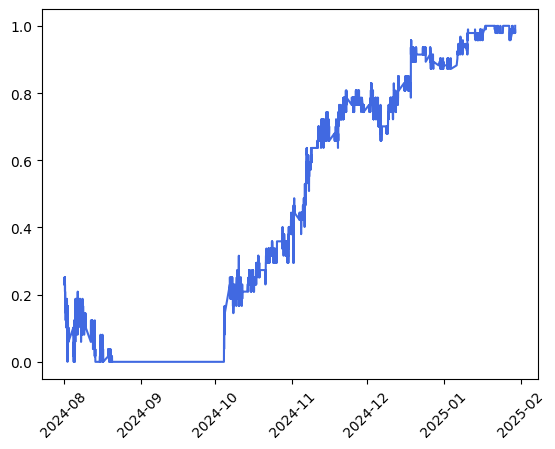

In [ ]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [ ]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_JAN_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)